# Homework 2 — NumPy and probability
**Ishan Bhardwaj · FM 5151**



In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})
print("NumPy version:", np.__version__)

NumPy version: 1.26.4


## 1. Numerical integration (30 points)
For $n$ equal partitions of $[a,b]$, let $h=(b-a)/n$. The three approximations are
$$L_n=h\sum_{i=0}^{n-1}f(a+ih),\qquad
R_n=h\sum_{i=0}^{n-1}f(a+(i+1)h),\qquad
M_n=h\sum_{i=0}^{n-1}f(a+(i+1/2)h).$$
The function evaluates all selected points together as a NumPy array. A negative $h$ also handles reversed integration limits.

In [2]:
def integrate(f, a, b, n, method="midpoint"):
    """Integrate a vectorizable f using n equal-width rectangles.

    method is 'left', 'right', or 'midpoint'.
    """
    if isinstance(n, (bool, np.bool_)) or not isinstance(n, (int, np.integer)) or n <= 0:
        raise ValueError("n must be a positive integer")
    offsets = {"left": 0.0, "right": 1.0, "midpoint": 0.5}
    if method not in offsets:
        raise ValueError("method must be 'left', 'right', or 'midpoint'")
    h = (b - a) / n
    x = a + (np.arange(n) + offsets[method]) * h
    values = np.broadcast_to(np.asarray(f(x), dtype=float), x.shape)
    return float(h * np.sum(values))

# Analytical example: integral from 0 to 1 of x^2 dx = 1/3.
exact = 1 / 3
print("Integral of x^2 on [0, 1]; exact =", exact)
print(f"{'n':>6} {'method':>10} {'approximation':>16} {'absolute error':>16}")
for n in (10, 100, 1000):
    for method in ("left", "right", "midpoint"):
        estimate = integrate(lambda x: x**2, 0, 1, n, method)
        print(f"{n:6d} {method:>10} {estimate:16.10f} {abs(estimate-exact):16.10f}")

# Independent finite-sum formulas for this particular integrand.
n = 100
assert np.isclose(integrate(lambda x: x**2, 0, 1, n, "left"),
                  1/3 - 1/(2*n) + 1/(6*n**2))
assert np.isclose(integrate(lambda x: x**2, 0, 1, n, "right"),
                  1/3 + 1/(2*n) + 1/(6*n**2))
assert np.isclose(integrate(lambda x: x**2, 0, 1, n, "midpoint"),
                  1/3 - 1/(12*n**2))
for method in ("left", "right", "midpoint"):
    assert np.isclose(integrate(lambda x: 3.0, 2, 5, 7, method), 9)
assert np.isclose(integrate(lambda x: x, 3, 1, 50), -4)
print("Integration checks passed.")

Integral of x^2 on [0, 1]; exact = 0.3333333333333333
     n     method    approximation   absolute error
    10       left     0.2850000000     0.0483333333
    10      right     0.3850000000     0.0516666667
    10   midpoint     0.3325000000     0.0008333333
   100       left     0.3283500000     0.0049833333
   100      right     0.3383500000     0.0050166667
   100   midpoint     0.3333250000     0.0000083333
  1000       left     0.3328335000     0.0004998333
  1000      right     0.3338335000     0.0005001667
  1000   midpoint     0.3333332500     0.0000000833
Integration checks passed.


For the increasing function $x^2$ on $[0,1]$, the left rule underestimates and the right rule overestimates. The midpoint rule underestimates here because the function is convex, but its error is much smaller. The displayed errors decrease as $n$ increases: the endpoint errors are of order $1/n$, while the midpoint error is of order $1/n^2$.

## 2. Correlated normal random variables (30 points)
Use the assignment's parameters
$$\mu=(0.1,0.2,0.3)^T,\quad \sigma=(0.4,0.2,0.3)^T,\quad
C=\begin{pmatrix}1&-0.4&0.7\\-0.4&1&0.2\\0.7&0.2&1\end{pmatrix}.$$
Set $D=\operatorname{diag}(\sigma)$, $\Sigma=DCD$, and factor $\Sigma=LL^T$. For independent standard-normal entries of $Z$, define $Y=\mu+LZ$.
Then $E[Y_{:,j}]=\mu$ and $\operatorname{Cov}(Y_{:,j})=LIL^T=\Sigma$. Each column is an independent draw of the three-dimensional vector; each row holds 100,000 draws of one marginal variable.

The assignment's `np.asarrray` is a spelling error; the function is `np.asarray`. Reshaping `mu` to `(3, 1)` broadcasts one mean across each row.

In [3]:
np.random.seed(20261006)
mu = np.asarray([0.1, 0.2, 0.3])
sigma = np.asarray([0.4, 0.2, 0.3])
C = np.asarray([[1.0, -0.4, 0.7],
                [-0.4, 1.0, 0.2],
                [0.7, 0.2, 1.0]])
N = 100000
m = 3
D = np.diag(sigma)
E = D @ C @ D  # E represents the covariance matrix Sigma.
L = np.linalg.cholesky(E)
Z = np.random.randn(m, N)
Y = mu[:, None] + L @ Z
assert Y.shape == (3, 100000)
assert np.all(np.linalg.eigvalsh(E) > 0)
assert np.allclose(L @ L.T, E)
print("Target covariance matrix:\n", E)
print("Cholesky factor:\n", L)
print("Y shape:", Y.shape)

Target covariance matrix:
 [[ 0.16  -0.032  0.084]
 [-0.032  0.04   0.012]
 [ 0.084  0.012  0.09 ]]
Cholesky factor:
 [[ 0.4       0.        0.      ]
 [-0.08      0.183303  0.      ]
 [ 0.21      0.157117  0.145651]]
Y shape: (3, 100000)


### 2(a). Pairwise correlations
`np.corrcoef(Y)` treats the rows as variables. The expected off-diagonal correlations are −0.4, 0.2, and 0.7 for pairs (1,2), (2,3), and (1,3), respectively.

In [4]:
sample_corr = np.corrcoef(Y)
print("Empirical correlation matrix:\n", sample_corr)
print("Empirical minus target:\n", sample_corr - C)

Empirical correlation matrix:
 [[ 1.       -0.405263  0.700486]
 [-0.405263  1.        0.194954]
 [ 0.700486  0.194954  1.      ]]
Empirical minus target:
 [[ 0.       -0.005263  0.000486]
 [-0.005263  0.       -0.005046]
 [ 0.000486 -0.005046  0.      ]]


The simulated correlations are close to the specified values. Exact equality is not expected with a finite random sample; the signs and relative strengths agree with the input matrix.

### 2(b). Means and standard deviations
The targets are the entries of `mu` and `sigma`. `axis=1` aggregates across the observations within each row. Here `ddof=0` describes the empirical distribution; `ddof=1` is also displayed for the conventional sample standard deviation.

In [5]:
sample_mu = Y.mean(axis=1)
sample_sd = Y.std(axis=1, ddof=0)
print("variable  target mean  sample mean  target SD  empirical SD  sample SD(ddof=1)")
for i in range(m):
    print(f"X{i+1}        {mu[i]:.6f}     {sample_mu[i]:.6f}    {sigma[i]:.6f}    "
          f"{sample_sd[i]:.6f}      {Y[i].std(ddof=1):.6f}")

variable  target mean  sample mean  target SD  empirical SD  sample SD(ddof=1)
X1        0.100000     0.101152    0.400000    0.401236      0.401238
X2        0.200000     0.199736    0.200000    0.201086      0.201087
X3        0.300000     0.301275    0.300000    0.300061      0.300063


Both the means and standard deviations are close to their targets, as expected. Small deviations are sampling error, and the two standard-deviation conventions are almost indistinguishable at this sample size.

### 2(c). Overlapping marginal histograms
Each row should be approximately bell-shaped. $X_1$ has the widest spread (SD 0.4), $X_2$ the narrowest (SD 0.2), and $X_3$ an intermediate spread (SD 0.3). Their centers should be 0.1, 0.2, and 0.3. Correlation affects the joint behavior, but does not alter these marginal distributions.

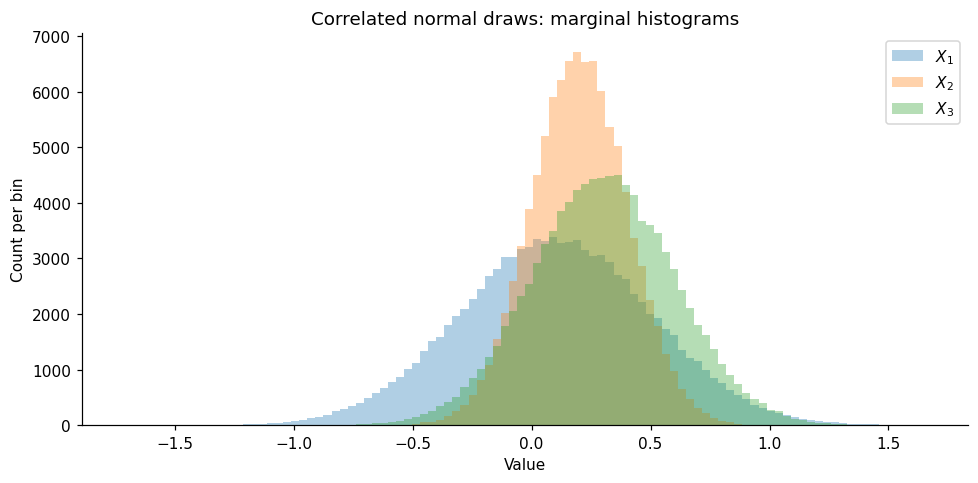

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(Y.min(), Y.max(), 101)
for i in range(m):
    ax.hist(Y[i], bins=bins, alpha=0.35, label=f"$X_{i+1}$")
ax.set(title="Correlated normal draws: marginal histograms",
       xlabel="Value", ylabel="Count per bin")
ax.legend()
fig.tight_layout()
plt.show()

The histograms show the expected centers, bell shapes, and relative widths. Using common bin edges makes the overlapping counts comparable.

### 2(d). Pairwise 2D histograms
The assignment illustrates these color plots with `hist2d`; darker/brighter colors encode the counts in two-dimensional bins. Pair (1,2) should slope downward, pair (2,3) should have a weak upward tilt, and pair (1,3) should have the strongest upward tilt.

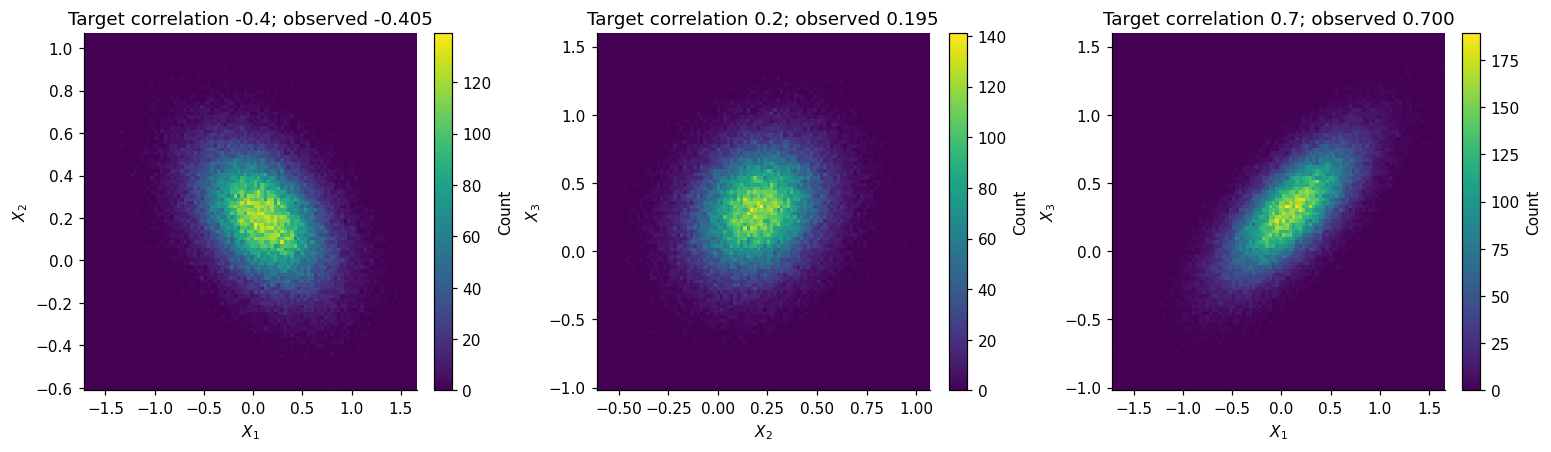

In [7]:
pairs = [(0, 1), (1, 2), (0, 2)]
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, (i, j) in zip(axs, pairs):
    hist = ax.hist2d(Y[i], Y[j], bins=100, cmap="viridis")
    ax.set(xlabel=f"$X_{i+1}$", ylabel=f"$X_{j+1}$",
           title=f"Target correlation {C[i,j]:.1f}; observed {sample_corr[i,j]:.3f}")
    fig.colorbar(hist[3], ax=ax, label="Count")
plt.show()

The three plots agree with the correlation structure: a moderate negative association, a weak positive association, and a stronger positive association. The different marginal standard deviations also affect the apparent widths of the clouds.

### 2(e). Proportions within 1, 2, and 3 standard deviations
For a normal variable, the theoretical proportions are approximately 0.682689, 0.954500, and 0.997300. The primary calculation uses the specified population mean and SD:
$$\widehat p_{i,k}=\frac1N\sum_{j=1}^N\mathbf{1}\{|Y_{ij}-\mu_i|\le k\sigma_i\}.$$
For completeness, a second table uses each row's estimated mean and SD. Correlation between rows does not change the theoretical marginal proportions.

In [8]:
normal_coverage = np.asarray([0.682689492, 0.954499736, 0.997300204])
coverage = np.empty((3, 3))
print("Using population parameters:")
print("k     X1        X2        X3        normal target")
for k in (1, 2, 3):
    mask = np.abs(Y - mu[:, None]) <= k * sigma[:, None]
    coverage[k-1] = mask.mean(axis=1)
    print(f"{k}  " + "  ".join(f"{p:.6f}" for p in coverage[k-1])
          + f"  {normal_coverage[k-1]:.6f}")
print("\nUsing empirical mean and SD:")
for k in (1, 2, 3):
    proportions = (np.abs(Y - sample_mu[:, None]) <= k * sample_sd[:, None]).mean(axis=1)
    print(f"{k}  " + "  ".join(f"{p:.6f}" for p in proportions))

Using population parameters:
k     X1        X2        X3        normal target
1  0.680640  0.680740  0.683750  0.682689
2  0.954470  0.953210  0.954480  0.954500
3  0.997150  0.997130  0.997200  0.997300

Using empirical mean and SD:
1  0.682100  0.683450  0.683750
2  0.955170  0.954290  0.954570
3  0.997210  0.997270  0.997190


The results follow the normal 68–95–99.7% rule, with small sampling differences. Estimating the centers and spreads from the same observations slightly changes the boundaries and thus the proportions.

### 2(f). Skewness — source convention and standardized definition
The supplied probability notes (page 10, visually checked) list $g(x)=(x-E[X])^3$ under “Skewness.” Taking its expectation gives the **third central moment**, which is not standardized. I report that quantity to follow the notes, and also the conventional dimensionless skewness:
$$\widehat m_3=\frac1N\sum_j(Y_{ij}-\bar Y_i)^3,\qquad
\widehat\gamma_1=\frac{\widehat m_3}{\widehat\sigma_i^3}.$$
These are empirical moment estimates using `ddof=0`, without finite-sample bias corrections. Both population quantities equal zero for a normal distribution.

In [9]:
centered = Y - sample_mu[:, None]
third_moment = np.mean(centered**3, axis=1)
skewness = third_moment / sample_sd**3
print("Third central moments (notes' unstandardized quantity):", third_moment)
print("Standardized skewness:", skewness)

Third central moments (notes' unstandardized quantity): [ 0.000238  0.000041 -0.000064]
Standardized skewness: [ 0.003689  0.005    -0.002373]


Both measures are close to zero, consistent with symmetric normal marginals. The third central moments have units cubed; standardized skewness permits comparison across the different scales.

### 2(g). Kurtosis
The notes use the standardized fourth moment, so this is **Pearson kurtosis**, with normal benchmark 3:
$$\widehat\beta_2=\frac1N\sum_j\left(\frac{Y_{ij}-\bar Y_i}{\widehat\sigma_i}\right)^4.$$
Excess kurtosis subtracts 3 and has normal benchmark zero; it is shown separately to avoid confusing the conventions.

In [10]:
kurtosis = np.mean((centered / sample_sd[:, None])**4, axis=1)
print("Pearson kurtosis (normal target 3):", kurtosis)
print("Excess kurtosis (normal target 0):", kurtosis - 3)

Pearson kurtosis (normal target 3): [2.999306 3.009119 3.005112]
Excess kurtosis (normal target 0): [-0.000694  0.009119  0.005112]


The fourth standardized moments are close to 3, so the simulated marginal tail behavior is consistent with the normal model.

## 3. Estimation (40 points)
### 3(a). Two uniform samples
Generate independent draws from $U(5,30)$, with sample sizes 10 and 100,000. A separate seed keeps this experiment reproducible independently of Question 2. NumPy's uniform generator uses a half-open interval in principle; excluding the right endpoint does not change probabilities for a continuous distribution.

In [11]:
np.random.seed(20261007)
a, b = 5.0, 30.0
u1 = np.random.uniform(a, b, size=10)
u2 = np.random.uniform(a, b, size=100000)
print("u1:", u1)
print("Sample sizes:", u1.size, u2.size)
assert u1.shape == (10,) and u2.shape == (100000,)

u1: [24.237219 16.76197  26.457685 24.345818  8.852636 19.160006  5.207788
 12.518375 26.008667 28.002634]
Sample sizes: 10 100000


### 3(b). $P(X_i\le 10)$
The uniform density is $1/(30-5)=1/25$, hence
$$P(X_i\le10)=\frac{10-5}{30-5}=\frac15=0.2.$$
Estimate this probability by the fraction of observations satisfying the event. The output compares absolute errors and identifies the closer sample in this particular run.

In [12]:
def compare_estimates(label, exact, estimate1, estimate2):
    errors = np.abs(np.asarray([estimate1, estimate2]) - exact)
    print(label)
    print(f"Analytical: {exact:.8f}")
    print(f"u1: {estimate1:.8f}; absolute error: {errors[0]:.8f}")
    print(f"u2: {estimate2:.8f}; absolute error: {errors[1]:.8f}")
    if errors[0] == errors[1]:
        print("The samples tie in absolute error.")
    else:
        print("Closer in this run:", "u1" if errors[0] < errors[1] else "u2")

compare_estimates("P(X <= 10)", (10-a)/(b-a),
                  np.mean(u1 <= 10), np.mean(u2 <= 10))

P(X <= 10)
Analytical: 0.20000000
u1: 0.20000000; absolute error: 0.00000000
u2: 0.20043000; absolute error: 0.00043000
Closer in this run: u1


### 3(c). $P(X_i>15\mid X_i>10)$
Because $\{X>15\}\subset\{X>10\}$,
$$P(X>15\mid X>10)=\frac{P(X>15)}{P(X>10)}
=\frac{(30-15)/25}{(30-10)/25}=\frac{15}{20}=0.75.$$
The denominator of the empirical estimate is the number satisfying the conditioning event, not the full sample size. If no observations satisfy it, the empirical conditional probability is undefined.

In [13]:
def conditional_estimate(u):
    condition = u > 10
    denominator = np.count_nonzero(condition)
    if denominator == 0:
        return np.nan
    return np.count_nonzero((u > 15) & condition) / denominator

print("Conditioning counts:", np.count_nonzero(u1 > 10), np.count_nonzero(u2 > 10))
compare_estimates("P(X > 15 | X > 10)", (b-15)/(b-10),
                  conditional_estimate(u1), conditional_estimate(u2))

Conditioning counts: 8 79957
P(X > 15 | X > 10)
Analytical: 0.75000000
u1: 0.87500000; absolute error: 0.12500000
u2: 0.74753930; absolute error: 0.00246070
Closer in this run: u2


### 3(d). $E[X_i]$
$$E[X_i]=\int_5^{30}\frac{x}{25}\,dx
=\frac{30^2-5^2}{50}=\frac{5+30}{2}=17.5.$$
Estimate this with the sample mean.

In [14]:
population_mean = (a + b) / 2
compare_estimates("E[X]", population_mean, u1.mean(), u2.mean())

E[X]
Analytical: 17.50000000
u1: 19.15527979; absolute error: 1.65527979
u2: 17.46578222; absolute error: 0.03421778
Closer in this run: u2


The printed comparisons answer which sample is closer for each quantity. Larger samples generally give more precise estimates, but are not guaranteed to win every individual comparison. For example, a sample of 10 can happen to contain exactly two observations at or below 10 and estimate 0.2 exactly. The law of large numbers describes convergence as sample size grows, not monotonic improvement on every realization.

### 3(e). 10,000 means of samples of size 10
For $X\sim U(a,b)$,
$$E[X^2]=\frac{b^3-a^3}{3(b-a)}=\frac{a^2+ab+b^2}{3},\qquad
\operatorname{Var}(X)=E[X^2]-E[X]^2=\frac{(b-a)^2}{12}=\frac{625}{12}.$$
For $n$ independent observations, the formulas in the notes (pages 12–13) give
$$E[\bar X_n]=17.5,\qquad \operatorname{Var}(\bar X_n)=\frac{625}{12n},\qquad
\operatorname{SD}(\bar X_n)=\frac{25}{\sqrt{12n}}.$$
Thus for $n=10$, the expected SD is approximately **2.282177**. Each row below is a fresh sample, and `mean(axis=1)` yields one mean per row. The reported SD across the 10,000 means uses `ddof=1`.

Sample size n = 10; repetitions = 10,000
Average of sample means: 17.50569485; theoretical: 17.50000000
SD of sample means: 2.26789281; theoretical: 2.28217732
Relative SD error: -0.626%
Monte Carlo SE of the average of means: 0.02282177


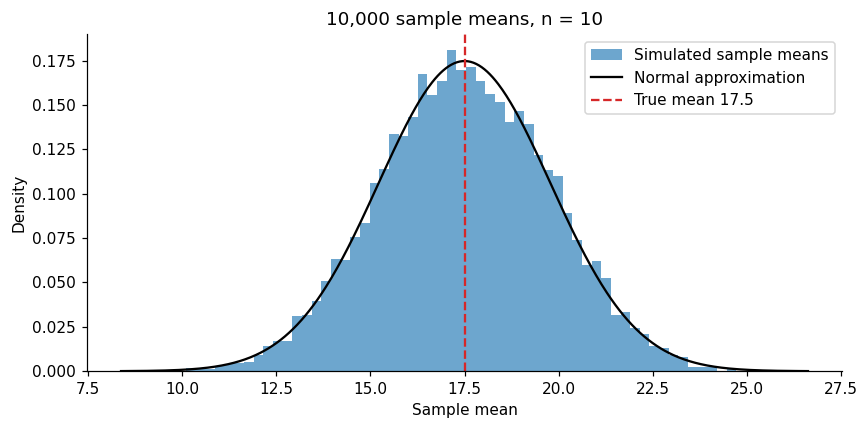

In [15]:
np.random.seed(20261008)
repetitions = 10000
population_sd = (b - a) / np.sqrt(12)
mean1 = np.random.uniform(a, b, size=(repetitions, 10)).mean(axis=1)

def summarize_means(means, sample_size):
    theoretical_sd = population_sd / np.sqrt(sample_size)
    print(f"Sample size n = {sample_size:,}; repetitions = {means.size:,}")
    print(f"Average of sample means: {means.mean():.8f}; theoretical: {population_mean:.8f}")
    print(f"SD of sample means: {means.std(ddof=1):.8f}; theoretical: {theoretical_sd:.8f}")
    print(f"Relative SD error: {means.std(ddof=1) / theoretical_sd - 1:.3%}")
    print(f"Monte Carlo SE of the average of means: {theoretical_sd / np.sqrt(means.size):.8f}")

summarize_means(mean1, 10)

def plot_means(means, sample_size):
    theoretical_sd = population_sd / np.sqrt(sample_size)
    x = np.linspace(population_mean - 4*theoretical_sd,
                    population_mean + 4*theoretical_sd, 500)
    density = np.exp(-0.5*((x-population_mean)/theoretical_sd)**2) / (theoretical_sd*np.sqrt(2*np.pi))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(means, bins=60, density=True, alpha=0.65, label="Simulated sample means")
    ax.plot(x, density, color="black", label="Normal approximation")
    ax.axvline(population_mean, color="tab:red", linestyle="--", label="True mean 17.5")
    ax.set(title=f"10,000 sample means, n = {sample_size:,}",
           xlabel="Sample mean", ylabel="Density")
    ax.legend()
    fig.tight_layout()
    plt.show()

plot_means(mean1, 10)

The average is close to 17.5 and the SD is close to 2.282177, agreeing with the unbiasedness and variance formulas. The histogram is approximately normal and symmetric, even though the original observations are uniform. For $n=10$ this is an approximation: the exact mean distribution is a rescaled sum of uniforms, with bounded support $[5,30]$.

### 3(f). 10,000 means of samples of size 100,000
The theoretical mean remains 17.5, but the SD is now
$$\frac{25}{\sqrt{12\cdot100000}}\approx 0.02282177.$$
The sample size is 10,000 times larger, so the SD of the sample mean is **100 times smaller** and its variance is **10,000 times smaller**.

A full `(10000, 100000)` float64 array would occupy 8 GB (about 7.45 GiB). Instead, generate **20 complete samples per batch**, immediately reduce each row to its mean, and discard the batch. Each batch occupies 16 MB (about 15.3 MiB); the final vector has only 10,000 entries. This still draws all one billion uniform values; it does not substitute draws from a normal approximation.

Uniform observations generated: 1,000,000,000
Maximum batch storage: 16.0 MB
Sample size n = 100,000; repetitions = 10,000
Average of sample means: 17.50013839; theoretical: 17.50000000
SD of sample means: 0.02254101; theoretical: 0.02282177
Relative SD error: -1.230%
Monte Carlo SE of the average of means: 0.00022822


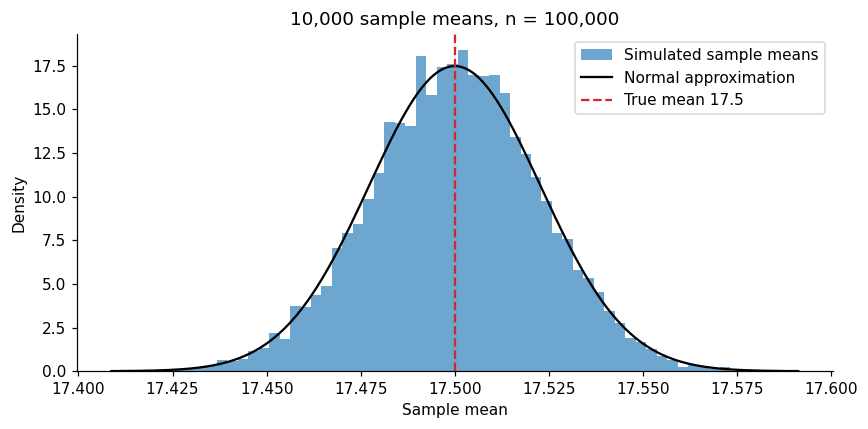

In [16]:
np.random.seed(20261009)
large_n = 100000
batch_size = 20
mean2 = np.empty(repetitions)
draw_count = 0
for start in range(0, repetitions, batch_size):
    stop = min(start + batch_size, repetitions)
    batch = np.random.uniform(a, b, size=(stop-start, large_n))
    mean2[start:stop] = batch.mean(axis=1)
    draw_count += batch.size
    del batch

assert draw_count == 1_000_000_000
assert mean2.shape == (10000,)
assert np.all(np.isfinite(mean2))
print(f"Uniform observations generated: {draw_count:,}")
print(f"Maximum batch storage: {batch_size * large_n * 8 / 1e6:.1f} MB")
summarize_means(mean2, large_n)
plot_means(mean2, large_n)

Both experiments are centered near the same population mean. The large-sample means are concentrated much more tightly around 17.5 and are well approximated by a normal distribution. The separate histograms use different horizontal ranges so both shapes remain visible; the comparison below shows the empirical SD ratio and puts both distributions on a common standardized scale.

Empirical SD ratio, n=10 divided by n=100000: 100.61183788411613
Theoretical SD ratio: 100.0


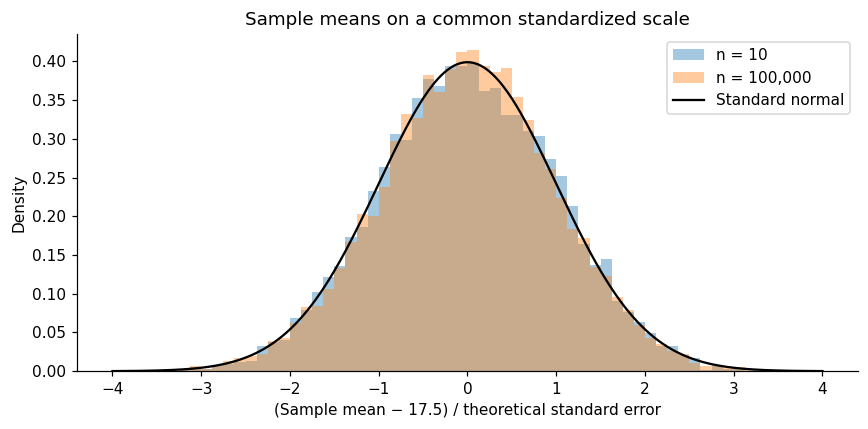

In [17]:
print("Empirical SD ratio, n=10 divided by n=100000:",
      mean1.std(ddof=1) / mean2.std(ddof=1))
print("Theoretical SD ratio:", np.sqrt(100000 / 10))
fig, ax = plt.subplots(figsize=(8, 4))
for means, sample_size in ((mean1, 10), (mean2, 100000)):
    standardized = (means - population_mean) / (population_sd / np.sqrt(sample_size))
    ax.hist(standardized, bins=np.linspace(-4, 4, 65), density=True,
            alpha=0.4, label=f"n = {sample_size:,}")
x = np.linspace(-4, 4, 500)
ax.plot(x, np.exp(-x**2/2)/np.sqrt(2*np.pi), color="black", label="Standard normal")
ax.set(title="Sample means on a common standardized scale",
       xlabel="(Sample mean − 17.5) / theoretical standard error", ylabel="Density")
ax.legend()
fig.tight_layout()
plt.show()

The central limit theorem explains the approximately normal standardized shapes; the law of large numbers explains the increasing concentration near 17.5. The average of 10,000 sample means also has simulation error: its theoretical standard error is the SD of a single sample mean divided by $\sqrt{10000}=100$. The displayed discrepancies should be interpreted in that context.

**Source clarification:** the probability notes' page 13 says “with probability 1,” while footnote 3 calls this the weak law. Convergence with probability 1 is the **strong** law; the weak law is convergence in probability. The variance calculation used here is $\operatorname{Var}(\bar X_n)=\operatorname{Var}(X)/n$ for independent draws and is unaffected by this terminology issue.

## Final numerical checks
The following checks verify the requested sample dimensions and broad agreement with the theoretical targets. The tolerances below are numerical sanity checks for this reproducible simulation, not formal hypothesis tests.

In [18]:
assert mean1.shape == mean2.shape == (10000,)
assert np.allclose(sample_corr, C, atol=0.015)
assert np.all(np.abs(sample_mu - mu) < 6 * sigma / np.sqrt(N))
assert np.allclose(sample_sd, sigma, rtol=0.02)
assert np.max(np.abs(coverage - normal_coverage[:, None])) < 0.01
assert np.max(np.abs(skewness)) < 0.08
assert np.max(np.abs(kurtosis - 3)) < 0.12
for means, sample_size in ((mean1, 10), (mean2, 100000)):
    theory_sd = population_sd / np.sqrt(sample_size)
    assert abs(means.mean() - population_mean) < 6 * theory_sd / np.sqrt(repetitions)
    assert abs(means.std(ddof=1) / theory_sd - 1) < 0.05
print("All checks passed. Every requested experiment was completed.")

All checks passed. Every requested experiment was completed.
